In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [2]:
base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
file_name = r"social_ads.csv"
file_path = os.path.join(base_path, file_name) 

In [3]:
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계, 데이터 전처리

In [4]:
# User ID: 삭제
# 수치형: Age, EstimatedSalary
# 분류형: User ID, Gender, Purchased
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
# User ID 삭제 
ads_df = df.drop("User ID", axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [7]:
# 구매 여부 확인 
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

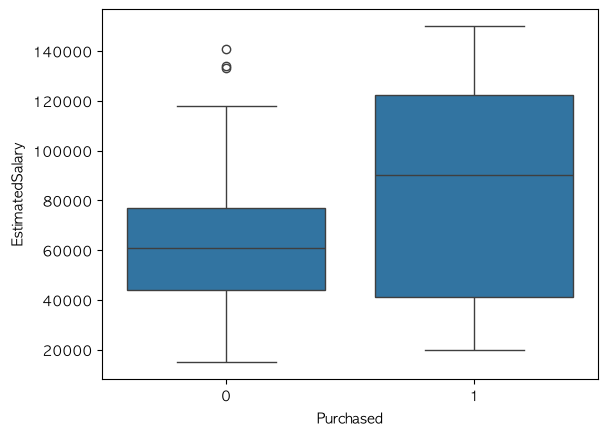

In [8]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

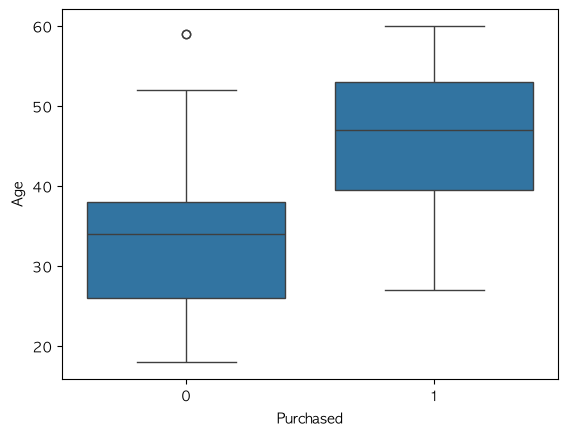

In [9]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()

In [10]:
ads_df.head(1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [11]:
# 수치형으로 변환 
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)

In [12]:
ads_df.head()

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [13]:
# 
X = ads_df.drop("Purchased", axis=1)
X.head(1)

,Age,EstimatedSalary,Gender_Male
0,19,19000,1


In [14]:
y = ads_df["Purchased"]
y.head(1)

0    0
Name: Purchased, dtype: int64

In [15]:
X.columns = ["Age", "Salary", "Gender"]

In [16]:
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유는 데이터 셋을 나누기 전에 전체 데이터를 스케일링하면  
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [17]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [18]:
# 1. 자르고 표준화한다
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계, 모델 준비

In [19]:
# Salary 연봉
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [20]:
# 선형회귀 모델(weight * x) + bias
# weight: 가중치
# bias: 절편
lr = LinearRegression()

In [21]:
lr.fit(X_train_salary, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3563
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.89]


In [22]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620513


### 결론 쓰레기

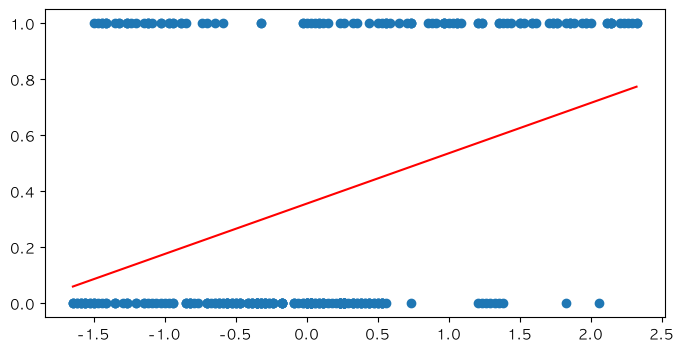

In [23]:
plt.figure(figsize=(8, 4))
plt.scatter(X_train_salary, y_train)

x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1, 1)
y_line = lr.predict(x_line)

plt.plot(x_line, y_line, color="red")
plt.show()

## 모델 준비

In [24]:
lr = LogisticRegression()

## 모델 학습

In [25]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

## 모델 예측

In [26]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

### 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미합니다.  
  현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측능력이 크게 떨어질 수 있습니다.  
  이런 현상을 과적합이라고 합니다.

In [27]:
print(f"훈련 데이터 점수: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수: {accuracy_score(y_test, y_pred)}")

훈련 데이터 점수: 0.853125
테스트 데이터 점수: 0.7875


In [28]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


In [29]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다는 나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다.
"""
None

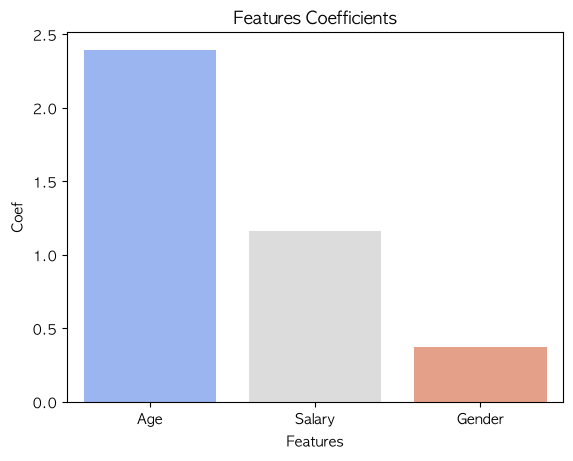

In [30]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

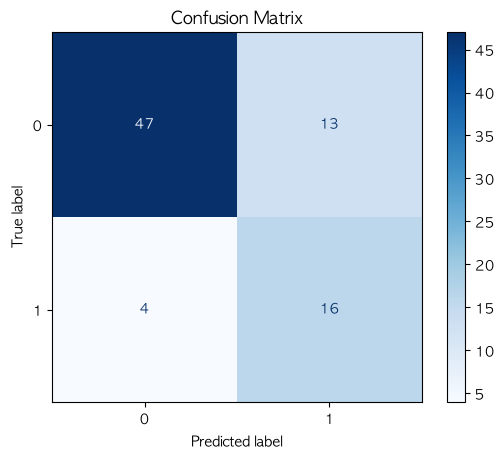

In [31]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [32]:
# % /Users/kdt_0900_lyn/ml/resoce/dataset
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

In [33]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


In [34]:
admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Target']

In [35]:
admission_df.info

<bound method DataFrame.info of      GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0          337          118                  4  4.5  4.5  9.65         1   
1          324          107                  4  4.0  4.5  8.87         1   
2          316          104                  3  3.0  3.5  8.00         1   
3          322          110                  3  3.5  2.5  8.67         1   
4          314          103                  2  2.0  3.0  8.21         0   
..         ...          ...                ...  ...  ...   ...       ...   
395        324          110                  3  3.5  3.5  9.04         1   
396        325          107                  3  3.0  3.5  9.11         1   
397        330          116                  4  5.0  4.5  9.45         1   
398        312          103                  3  3.5  4.0  8.78         0   
399        333          117                  4  5.0  4.0  9.66         1   

     Target  
0         1  
1         1  
2         0  

In [36]:
admission_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


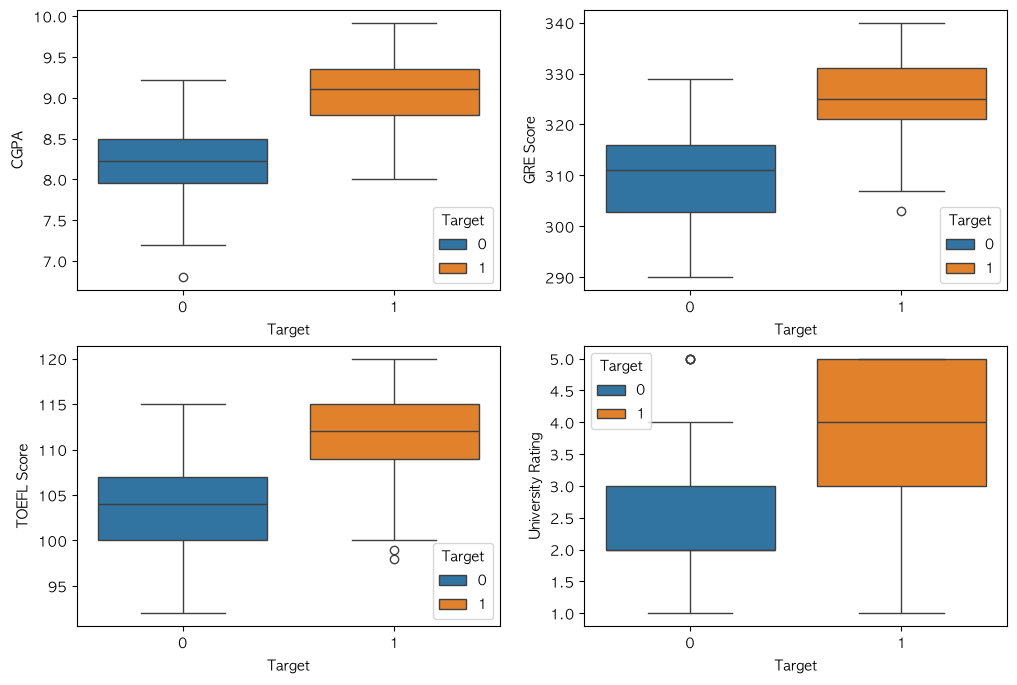

In [37]:
features = ["CGPA", "GRE Score", "TOEFL Score", "University Rating"]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(admission_df, x="Target", y=feature, hue="Target")
    
plt.show()

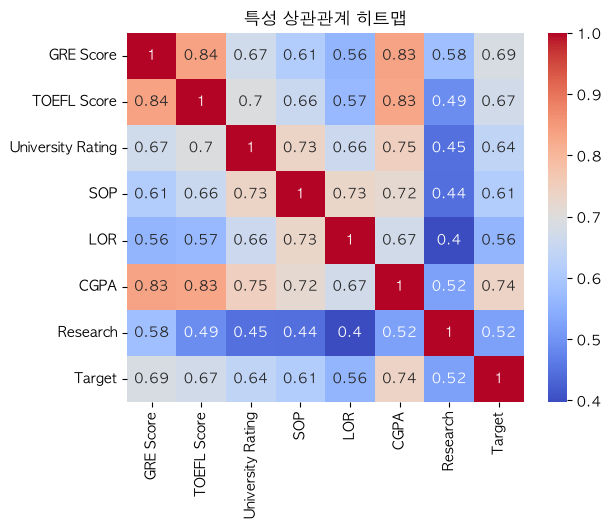

In [38]:
corr = admission_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("특성 상관관계 히트맵")
plt.show()

In [39]:
X = admission_df.drop("Target", axis=1)
X.head(3)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1


In [40]:
y= admission_df["Target"]
y.head()

0    1
1    1
2    0
3    1
4    0
Name: Target, dtype: int64

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [42]:
vif = [variance_inflation_factor(X.values, i) for  i in range(X.shape[1])]
print(vif)
print(X.columns)

[np.float64(4.615516166781605), np.float64(4.2889590137468945), np.float64(2.9196056618253396), np.float64(3.075503721954348), np.float64(2.4312584848694407), np.float64(5.207402545736424), np.float64(1.5433119011502872)]
Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='str')


In [43]:
# 데이터 분할 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [44]:
                                    # Ridge, Lasso : 선형 보델에서 규제하는 모델 (Ridge: 기울기 폭주를 줄이기 )(Lasso: 영향력을 안주는 값을 0으로 바꿈 )
from sklearn.linear_model import LinearRegression, Ridge, Lasso
                            # 예측이 얼마나 틀렸는지 채점하는 도구
from sklearn.metrics import mean_squared_error

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.
- 
#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

## 데이터 표준화 \

In [45]:
# 크기 차이를 맞추는 작업
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
models = {
    # 규제가 없는 기본 선형회귀
    "LinearRegression": LinearRegression(),
    # 수가 너무 커지지 않도록 제곱 기준의 규제를 추가한 회귀
    "Ridge": Ridge(alpha=1.0),
    # 수의 절댓값 기준 규제를 적용하며, 영향이 약한 특성의 계수를 정확히 0으로 만들 수 있음
    "Lasso": Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = model.predict(X_test_scaled)    
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "Acurracy": acc
    })

    coef_df[name] = model.coef_

In [47]:
coef_df
result_df = pd.DataFrame(result)
result_df

,Model,MSE,RMSE,Acurracy
0,LinearRegression,0.101292,0.318264,0.8625
1,Ridge,0.101213,0.318139,0.8625
2,Lasso,0.101332,0.318326,0.8875


In [48]:
coef_df.sort_values(by="LinearRegression", ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.170626,0.168599,0.169111
GRE Score,0.076086,0.076236,0.075305
University Rating,0.069660,0.069725,0.066634
Research,0.064450,0.064335,0.058810
SOP,0.055002,0.054779,0.048769
TOEFL Score,0.009755,0.010982,0.008198
LOR,-0.004585,-0.003801,0.000000


In [49]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


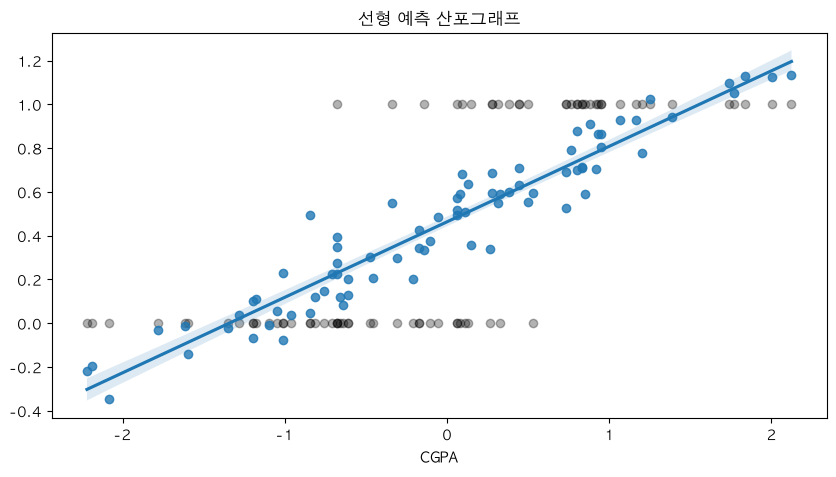

In [50]:
plt.figure(figsize=(10, 5))

plt.scatter(X_test_scaled_df["CGPA"], y_test, color="black", alpha=0.3, label="Actual")
sns.regplot(x=X_test_scaled_df["CGPA"], y=model.predict(X_test_scaled))

plt.title("선형 예측 산포그래프")
plt.show()

In [51]:
lr = LogisticRegression()

In [52]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [53]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [54]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_percent = y_prob * 100

for i, proba in enumerate(y_prob_percent[:20], 1):
    print(f"샘플 {i}번의 합격 확률 : {proba:.2f}%")

샘플 1번의 합격 확률 : 98.86%
샘플 2번의 합격 확률 : 5.62%
샘플 3번의 합격 확률 : 6.88%
샘플 4번의 합격 확률 : 0.09%
샘플 5번의 합격 확률 : 0.24%
샘플 6번의 합격 확률 : 14.38%
샘플 7번의 합격 확률 : 24.86%
샘플 8번의 합격 확률 : 0.24%
샘플 9번의 합격 확률 : 6.15%
샘플 10번의 합격 확률 : 99.88%
샘플 11번의 합격 확률 : 80.96%
샘플 12번의 합격 확률 : 0.35%
샘플 13번의 합격 확률 : 96.18%
샘플 14번의 합격 확률 : 99.66%
샘플 15번의 합격 확률 : 98.39%
샘플 16번의 합격 확률 : 89.61%
샘플 17번의 합격 확률 : 75.23%
샘플 18번의 합격 확률 : 0.29%
샘플 19번의 합격 확률 : 52.76%
샘플 20번의 합격 확률 : 94.89%


In [55]:
acc = accuracy_score(y_test, y_pred)
print(f"로지스틱 회귀 정확도 : {acc}")

로지스틱 회귀 정확도 : 0.8875


In [56]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


AttributeError: Rectangle.set() got an unexpected keyword argument 'X'

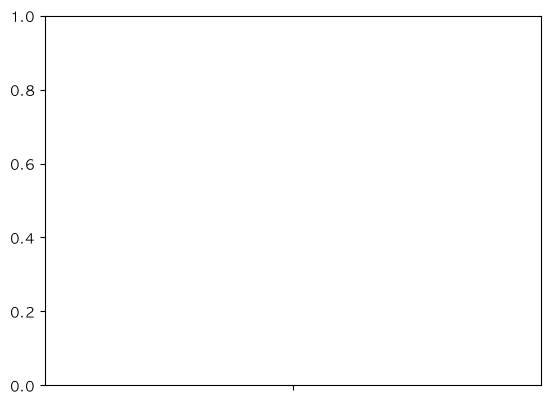

In [57]:
sns.barplot(coef_df, X="Features", y="Coef", palette="coolwarm", hue="Features")
plt.title("Feature 계수 ")
plt.xlabel("특성 (Features)")
plt.ylabel("가중치 ()")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))